# pynonthermal quickstart

`pynonthermal` solves the Spencer-Fano equation, which gives the energy distribution y(E) of the
non-thermal electrons that slow down in a plasma, and the share of the deposited energy that goes to
heating, to ionisation, and to excitation.

You describe the plasma, then solve it. A `Plasma` holds no energy grid and no deposition rate, so the
same one can be solved on any grid and at any rate.

In [1]:
import matplotlib_inline.backend_inline

import pynonthermal

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

## A pure-oxygen plasma (Kozma & Fransson 1992, Figure 2)

The gas is oxygen with an electron fraction $x_e = 0.01$, so one per cent of it is O II and the rest is
O I. `Fixed` gives the ion fractions, and `excitation=True` adds the bound-bound excitations of every
stage with LTE level populations at the temperature of the plasma.

In [2]:
n_e = 1e8  # free electron density [cm^-3]
x_e = 1e-2  # ionisation fraction n_OII / (n_OI + n_OII)
n_oxygen = n_e / x_e

plasma = pynonthermal.Plasma(
    temperature=6000,  # K, for the LTE level populations
    elements=[
        pynonthermal.Element(
            Z=8,
            n_elem=n_oxygen,
            populations=pynonthermal.Fixed({1: 1 - x_e, 2: x_e}),
            excitation=True,
        )
    ],
)
plasma

Plasma(elements=[Element(Z=8, n_elem=10000000000.0, populations=Fixed(ion_fractions={1: 0.99, 2: 0.01}), excitation=True, builtin_channels=True, ionisation_channels=(), excitations=())], temperature=6000, free_electron_density=None, adata_polars=None, use_collstrengths=True, maxnlevelslower=5, maxnlevelsupper=250)

`solve_spencerfano()` takes the plasma, the deposition rate density, and the energy grid. `emin_ev=1`
matches the low-energy cutoff $E_0$ of Kozma & Fransson (1992); an electron that falls below it is taken
to have thermalised, so its remaining energy counts as heating.

With fixed ion densities the energy fractions do not depend on the deposition rate density, and the rate
coefficients scale with it.

In [3]:
result = pynonthermal.solve_spencerfano(
    plasma,
    deposition_ev_per_s_per_cm3=2950.49 * n_oxygen,
    emin_ev=1,
    emax_ev=3000,
    npts=4096,
)

print(f"heating:    {result.frac_heating:.4f}")
print(f"ionisation: {result.frac_ionisation:.4f}")
print(f"excitation: {result.frac_excitation:.4f}")
print(f"sum:        {result.frac_sum:.4f}   (one when the grid resolves every channel)")

Reading artis_files/transitiondata.txt.zst...
  took 0.10 seconds
Reading artis_files/adata.txt
heating:    0.3703
ionisation: 0.5715
excitation: 0.0575
sum:        0.9992   (one when the grid resolves every channel)


## The degradation spectrum

y(E) is the flux of non-thermal electrons per unit energy. It rises towards low energies as the fast
electrons of the source degrade.

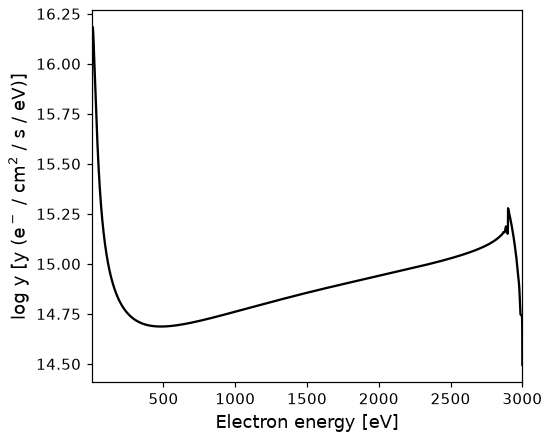

In [4]:
result.plot_yspectrum()

## Where the energy goes

Each curve is E d$\eta$/dE, the contribution of the electrons at one energy to a deposition channel. The
area under a curve is that channel's share of the deposited energy.

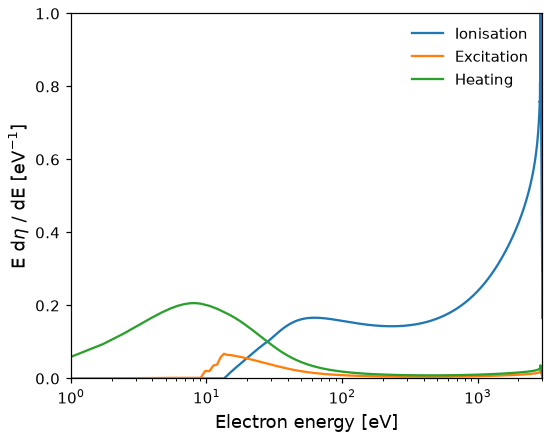

In [5]:
result.plot_channels(xscalelog=True)

## Rates for a plasma code

The ionisation rate coefficient is per ion in s$^{-1}$. Multiply it by the ion number density for
ionisations per second per cm$^3$.

In [6]:
print(f"O I  ionisation rate coefficient: {result.ionisation_ratecoeff(Z=8, ion_stage=1):.3e} s^-1")
print(f"O II ionisation rate coefficient: {result.ionisation_ratecoeff(Z=8, ion_stage=2):.3e} s^-1")
print(f"O I  effective ionisation potential: {result.eff_ionpot(Z=8, ion_stage=1):.2f} eV")

O I  ionisation rate coefficient: 1.050e+02 s^-1
O II ionisation rate coefficient: 3.487e+01 s^-1
O I  effective ionisation potential: 28.09 eV


An excitation is keyed by (lower level index, upper level index). Multiply its rate coefficient by the
population of the lower level for excitations per second per cm$^3$.

In [7]:
# the ground level of O II up to its eighth excited level
print(f"{result.excitation_ratecoeff(Z=8, ion_stage=2, transitionkey=(0, 8)):.3e} s^-1")
print("first few transitions of O II:", result.transitionkeys(8, 2)[:5])

1.086e-04 s^-1
first few transitions of O II: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]


## The ion populations

`Fixed` gives them back as you set them. `Saha` and `IonBalance` work out the ion fractions and the
free electron density for you: see the
[iron ionisation balance notebook](https://github.com/lukeshingles/pynonthermal/blob/main/fe_ionbalance_sn1a.ipynb).

In [8]:
print("ion fractions:  ", {stage: round(frac, 4) for stage, frac in result.ion_fractions(8).items()})
print(f"n_e:             {result.n_e:.3e} cm^-3")
print(f"n_e (nonthermal):{result.n_e_nt:.3e} cm^-3")

ion fractions:   {1: 0.99, 2: 0.01}
n_e:             1.000e+08 cm^-3
n_e (nonthermal):3.236e+09 cm^-3


For the full per-ion and per-shell breakdown, call `result.print_analysis()`.